In [60]:
import tensorflow as tf
# Outras importacoes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, GlobalMaxPooling1D, Conv1D, Dropout, MaxPooling1D, BatchNormalization, Dense
from tensorflow.keras.models import Model

In [61]:
import tensorflow_datasets as tfds

# Pegando o dataset, vi que no tensorflow ja esta separado os de teste, treino e validacao
# O as_supervised=True é para retorna apenas os labels e texts
(ds_train, ds_val, ds_test), info = tfds.load('scicite', split=['train', 'validation', 'test'], with_info=True, as_supervised=True)
print(info.features['label'].names)

['method', 'background', 'result']


In [63]:
df_train = tfds.as_dataframe(ds_train, info)
df_test = tfds.as_dataframe(ds_test, info)
df_val = tfds.as_dataframe(ds_val, info)

df_train.head()

,label,string
0,2,b'The finding that BMI is closely related to T...
1,1,b'The average magnitude of the NBR increases w...
2,2,b'It has been reported that NF-\xce\xbaB activ...
3,1,"b', 2008; Quraan and Cheyne, 2008; Quraan and ..."
4,1,"b'5B), but, interestingly, they shared conserv..."


In [65]:
# Renomei as colunas
df_train.columns, df_test.columns, df_val.columns = ['labels', 'data'], ['labels', 'data'], ['labels', 'data']
df_train.head()

,labels,data
0,2,b'The finding that BMI is closely related to T...
1,1,b'The average magnitude of the NBR increases w...
2,2,b'It has been reported that NF-\xce\xbaB activ...
3,1,"b', 2008; Quraan and Cheyne, 2008; Quraan and ..."
4,1,"b'5B), but, interestingly, they shared conserv..."


In [67]:
y_train = df_train['labels'].values
y_test  = df_test['labels'].values
y_val   = df_val['labels'].values
# Descobri que o tfds.as_dataframe armazena os textos em bytes, então tem que decodificar eles
x_train = df_train['data'].str.decode('utf-8')
x_test   = df_test['data'].str.decode('utf-8')
x_val  = df_val['data'].str.decode('utf-8')
print(f'Treino: { len(x_train)}\nVal: {len(x_val)}\nTeste: {len(x_test)}')

Treino: 8194
Val: 916
Teste: 1859


In [71]:
MAX_VOCAB_SIZE = 20000
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(x_train)

sequence_train = tokenizer.texts_to_sequences(x_train)
sequence_val = tokenizer.texts_to_sequences(x_val)
sequence_test = tokenizer.texts_to_sequences(x_test)

In [72]:
word2idx = tokenizer.word_index
V = len(word2idx)
print('Found %s unique tokens.' % V)

data_train = pad_sequences(sequence_train)
T = data_train.shape[1]
print('Shape of data train tensor:', data_train.shape)

data_val  = pad_sequences(sequence_val,  maxlen=T)
data_test = pad_sequences(sequence_test, maxlen=T)
print('Shape of data test tensor:', data_test.shape)

Found 30559 unique tokens.
Shape of data train tensor: (8194, 499)
Shape of data test tensor: (1859, 499)


In [76]:
# Construcao do modelo, dei uma misturada de dois codigos das aulas
D = 20
i = Input(shape=(T,))
x = Embedding(V + 1, D)(i)
x = Conv1D(32, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(64, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(128, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(3, activation='softmax')(x)

model = Model(i, x)

In [77]:
from tensorflow.keras.optimizers import Adam

# Compila o modelo
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy', # Os labels ja sao inteiros
    metrics=['accuracy']
)

In [78]:
# Treina o modelo
r = model.fit(
    data_train, 
    y_train, 
    batch_size=16,
    epochs=15,
    validation_data=(data_val, y_val)
)

Epoch 1/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5793 - loss: 0.9646 - val_accuracy: 0.5873 - val_loss: 0.9332
Epoch 2/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.5906 - loss: 0.9286 - val_accuracy: 0.5873 - val_loss: 0.9168
Epoch 3/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.5962 - loss: 0.8645 - val_accuracy: 0.6463 - val_loss: 0.8430
Epoch 4/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7228 - loss: 0.6744 - val_accuracy: 0.6965 - val_loss: 0.7519
Epoch 5/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7880 - loss: 0.5055 - val_accuracy: 0.6889 - val_loss: 0.7633
Epoch 6/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8179 - loss: 0.4182 - val_accuracy: 0.7063 - val_loss: 0.8300
Epoch 7/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8460 - loss: 0.3522 - val_accuracy: 0.6998 - val_loss: 0.8892
Epoch 8/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8747 - loss: 0.3011 - val_acc

In [79]:
# Validadando
resultado = model.evaluate(data_test, y_test)
print(f'Acurácia no teste: {resultado[1]}')
print(f'Loss no teste: {resultado[0]}')

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6541 - loss: 1.6881
Acurácia no teste: 0.6541151404380798
Loss no teste: 1.6881403923034668


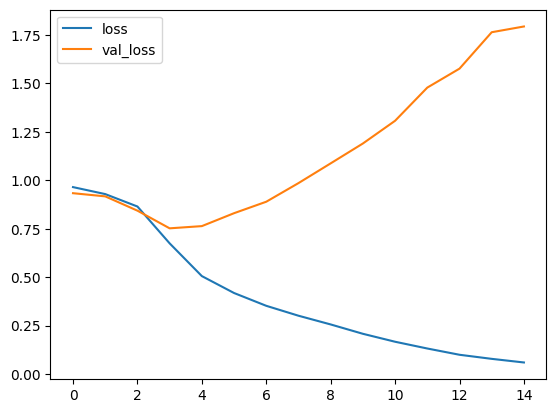

In [80]:
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

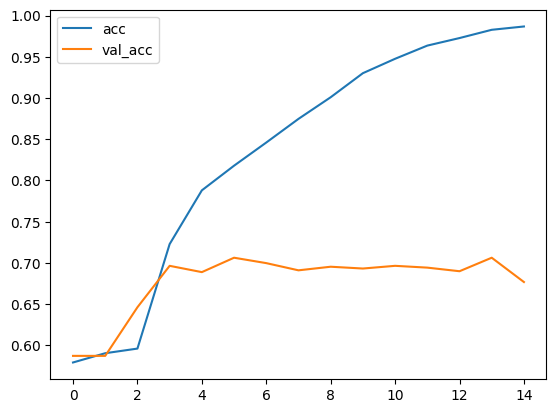

In [81]:
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

In [82]:
model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)          │ (None, 499)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_10 (Embedding)             │ (None, 499, 20)             │         611,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_24 (Conv1D)                   │ (None, 497, 32)             │           1,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_14 (MaxPooling1D)      │ (None, 165, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_25 (Conv1D)                   │ (None, 163, 64)             │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_15 (MaxPooling1D)      │ (None, 54, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_26 (Conv1D)                   │ (None, 52, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_10              │ (None, 128)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,957,547 (7.47 MB)

 Trainable params: 652,515 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,305,032 (4.98 MB)